# medeval Demo

PyTorch-native evaluation metrics for medical imaging: 2D/3D segmentation, classification, detection, and registration with physical spacing support, bootstrap CI, and visualization.


In [1]:
# Install dependencies (run once)
%pip install -U medeval torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import medeval
import matplotlib

print(f"medeval: {medeval.__version__}, torch: {torch.__version__}, matplotlib: {matplotlib.__version__}, device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

medeval: 0.1.4, torch: 2.8.0, matplotlib: 3.9.4, device: cpu


## 1. Segmentation Metrics

Overlap (Dice, Jaccard, Precision, Recall, Volumetric Similarity) and surface distances (Hausdorff, HD95, ASSD) with physical spacing support.


In [3]:
from medeval.metrics.segmentation import compute_segmentation_metrics

# 3D binary segmentation: shape (B, C, D, H, W), anisotropic spacing (dz, dy, dx) in mm
torch.manual_seed(0)
pred = (torch.rand(1, 1, 32, 64, 64) > 0.5).int()
target = (torch.rand(1, 1, 32, 64, 64) > 0.5).int()
spacing = (3.0, 1.0, 1.0)  # 3mm slice thickness, 1mm in-plane

# Basic overlap metrics
results = compute_segmentation_metrics(pred, target, spacing=spacing, include_surface=False)
print("Overlap metrics:")
for k, v in results.items():
    print(f"  {k}: {v.item():.4f}" if hasattr(v, 'item') else f"  {k}: {v:.4f}")

Overlap metrics:
  dice: 0.4992
  jaccard: 0.3326
  precision: 0.4978
  recall: 0.5007
  volumetric_similarity: 0.9971


In [4]:
# Surface distance metrics (use smaller volume for speed)
pred_small = torch.zeros(1, 1, 10, 20, 20)
target_small = torch.zeros(1, 1, 10, 20, 20)
pred_small[0, 0, 2:6, 5:15, 5:15] = 1  # cube
target_small[0, 0, 3:7, 6:16, 6:16] = 1  # shifted cube

results_surface = compute_segmentation_metrics(pred_small, target_small, spacing=(3.0, 1.0, 1.0), include_surface=True)
print("Surface distances (mm):")
for k, v in results_surface.items():
    unit = " mm" if "hausdorff" in k.lower() or "assd" in k.lower() else ""
    print(f"  {k}: {v.item():.4f}{unit}" if hasattr(v, 'item') else f"  {k}: {v:.4f}{unit}")

Surface distances (mm):
  dice: 0.6075
  jaccard: 0.4363
  precision: 0.6075
  recall: 0.6075
  volumetric_similarity: 1.0000
  hausdorff: 3.3166 mm
  hausdorff_95: 3.1623 mm
  assd: 1.8106 mm
  surface_dice: 0.4890


In [5]:
# Multi-class segmentation with integer labels (class indices 0, 1, 2)
# Uses the fixed multi-class Dice implementation that properly handles integer labels
from medeval.metrics.segmentation import dice_score

torch.manual_seed(42)
pred_multi = torch.randint(0, 3, (4, 1, 16, 32, 32))  # 4 cases, 3 classes
target_multi = torch.randint(0, 3, (4, 1, 16, 32, 32))

# Test different reduction strategies
print("Multi-class segmentation with integer labels:")
for reduction in ['none', 'mean-case', 'global']:
    d = dice_score(pred_multi, target_multi, reduction=reduction)
    if hasattr(d, 'shape') and d.numel() > 1:
        # Per-case results
        print(f"  reduction='{reduction}': dice shape={d.shape}, mean={d.mean().item():.4f}")
    else:
        val = d.item() if hasattr(d, 'item') else d
        print(f"  reduction='{reduction}': dice={val:.4f}")


Multi-class segmentation with integer labels:
  reduction='none': dice shape=torch.Size([4, 3]), mean=0.3302
  reduction='mean-case': dice=0.3302
  reduction='global': dice=0.3302


## 2. Classification Metrics

AUROC, AUPRC, accuracy, F1, MCC, Cohen's kappa, calibration (ECE, Brier), with bootstrap confidence intervals.


In [6]:
from medeval.metrics.classification import compute_classification_metrics

np.random.seed(0)
probs = np.random.rand(200)
labels = (np.random.rand(200) > 0.75).astype(int)  # ~25% positive

# Basic classification metrics
cls_results = compute_classification_metrics(probs, labels)
print("Classification metrics:")
for k, v in cls_results.items():
    if isinstance(v, tuple):  # CI tuple
        print(f"  {k}: {v[0]:.4f} [{v[1]:.4f}, {v[2]:.4f}]")
    elif hasattr(v, 'item'):
        print(f"  {k}: {v.item():.4f}")
    else:
        print(f"  {k}: {v:.4f}")

Classification metrics:
  auroc: 0.5085
  auprc: 0.3148
  accuracy: 0.4650
  balanced_accuracy: 0.4733
  sensitivity: 0.4902
  specificity: 0.4564
  f1: 0.4391
  mcc: -0.0467
  cohen_kappa: -0.0394


In [7]:
# With bootstrap 95% CI and calibration metrics
cls_with_ci = compute_classification_metrics(
    probs, labels, 
    compute_ci=True, 
    confidence=0.95, 
    include_calibration=True
)
print("\nWith CI and calibration:")
for k, v in cls_with_ci.items():
    if isinstance(v, tuple) and len(v) == 3:
        print(f"  {k}: {v[0]:.4f} [95% CI: {v[1]:.4f}, {v[2]:.4f}]")
    elif hasattr(v, 'item'):
        print(f"  {k}: {v.item():.4f}")
    else:
        print(f"  {k}: {v:.4f}")


With CI and calibration:
  auroc: 0.5085 [95% CI: 0.4961, 0.5208]
  auprc: 0.3148 [95% CI: 0.3148, 0.3148]
  accuracy: 0.4650
  balanced_accuracy: 0.4733
  sensitivity: 0.4902
  specificity: 0.4564
  f1: 0.4391
  mcc: -0.0467
  cohen_kappa: -0.0394
  ece: 0.4903
  aece: 0.4889
  tace: 0.4689
  brier: 0.3259


## 3. Detection Metrics

IoU, mAP, FROC for 2D/3D bounding box and instance segmentation.

In [8]:
from medeval.metrics.detection import compute_detection_metrics, box_iou_3d

# 3D bounding boxes: [x1, y1, z1, x2, y2, z2, score, class_id]
pred_boxes = torch.tensor([
    [10, 10, 5, 30, 30, 15, 0.9, 0],   # High confidence class 0 (matches GT)
    [50, 50, 10, 70, 70, 20, 0.8, 0],  # Medium confidence class 0 (FP - no matching GT)
    [80, 80, 5, 100, 100, 15, 0.7, 1], # Class 1 (matches GT)
], dtype=torch.float32)

gt_boxes = torch.tensor([
    [12, 12, 6, 32, 32, 16, 1.0, 0],   # Ground truth class 0
    [82, 82, 6, 102, 102, 16, 1.0, 1], # Ground truth class 1
], dtype=torch.float32)

det_results = compute_detection_metrics(
    pred_boxes, gt_boxes, 
    iou_thresholds=[0.5, 0.75], 
    use_3d=True,
    include_froc=True
)

print("Detection metrics:")
for k, v in det_results.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: array of length {len(v)}")
    elif hasattr(v, 'item'):
        print(f"  {k}: {v.item():.4f}")
    else:
        print(f"  {k}: {v:.4f}")


Detection metrics:
  iou_mean: 0.3824
  mAP@0.50: 1.0000
  mAP@0.75: 0.0000
  mAP@[.50:.95]: 0.5000
  precision: 0.6667
  recall: 1.0000
  froc_sensitivity: array of length 3
  froc_avg_fps: array of length 3
  froc_thresholds: array of length 3


## 4. Registration Metrics

Landmark TRE, image similarity (NMI, NCC), and deformation field quality (Jacobian determinant).


In [9]:
from medeval.metrics.registration import compute_registration_metrics, normalized_mutual_information

# Landmark-based: predicted vs ground truth landmark positions (N, 3) in mm
pred_landmarks = torch.tensor([[10.0, 20.0, 30.0], [40.0, 50.0, 60.0], [70.0, 80.0, 90.0]])
gt_landmarks = torch.tensor([[10.5, 20.2, 30.1], [40.8, 50.5, 60.3], [71.0, 81.0, 91.0]])

# Deformation field: (3, Z, H, W) displacement vectors
torch.manual_seed(0)
deformation = torch.randn(3, 16, 32, 32) * 0.1

reg_results = compute_registration_metrics(
    pred_landmarks=pred_landmarks, 
    target_landmarks=gt_landmarks,
    deformation_field=deformation,
    spacing=(2.0, 1.0, 1.0)
)

print("Registration metrics:")
for k, v in reg_results.items():
    if isinstance(v, dict):
        print(f"  {k}:")
        for k2, v2 in v.items():
            if isinstance(v2, np.ndarray):
                print(f"    {k2}: array of shape {v2.shape}")
            elif isinstance(v2, float):
                print(f"    {k2}: {v2:.4f}")
            else:
                print(f"    {k2}: {v2}")
    elif isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


Registration metrics:
  tre:
    mean: 1.7257
    median: 1.7029
    95th_percentile: 2.3748
    per_landmark: array of shape (3,)
  jacobian:
    mean: 1.0000
    median: 0.9965
    std: 0.1177
    min: 0.5144
    max: 1.5871
    folding_percentage: 0.0000
  bending_energy: 66459032.0000
  smoothness:
    average_gradient_magnitude: 0.1233
    bending_energy: 66459032.0000


## 5. Visualization

ROC/PR curves, calibration plots, and error distributions.


Available vis functions: ['plot_3d_slices', 'plot_calibration_comparison', 'plot_confidence_histogram', 'plot_decision_curve', 'plot_error_histogram', 'plot_froc_curve', 'plot_metric_distribution', 'plot_multiple_pr_curves', 'plot_multiple_roc_curves', 'plot_per_class_metrics', 'plot_pr_curve', 'plot_prediction_comparison', 'plot_reliability_diagram', 'plot_roc_curve', 'plot_segmentation_overlay', 'plot_stratified_results']


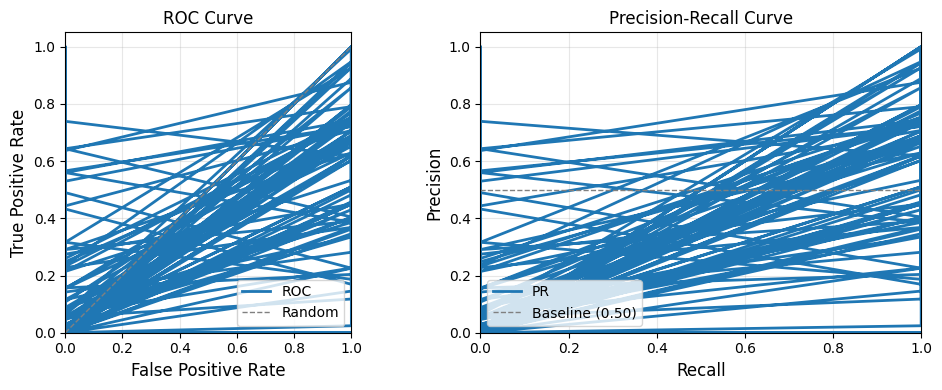

In [ ]:
import medeval.vis as vis
import matplotlib.pyplot as plt

# Check what's available
available = [f for f in dir(vis) if not f.startswith('_') and callable(getattr(vis, f, None))]
print(f"Available vis functions: {available}")

# Generate sample data for visualization
np.random.seed(42)
y_true = np.random.randint(0, 2, 200)
# Create scores that are correlated with labels for realistic plots
y_score = np.clip(y_true * 0.6 + np.random.randn(200) * 0.3, 0, 1)

# ROC and PR curves
# Use plot_roc_from_predictions / plot_pr_from_predictions for raw y_true/y_score
# These functions compute the curve points internally using sklearn
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vis.plot_roc_from_predictions(y_true, y_score, ax=axes[0])
axes[0].set_title('ROC Curve')

vis.plot_pr_from_predictions(y_true, y_score, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


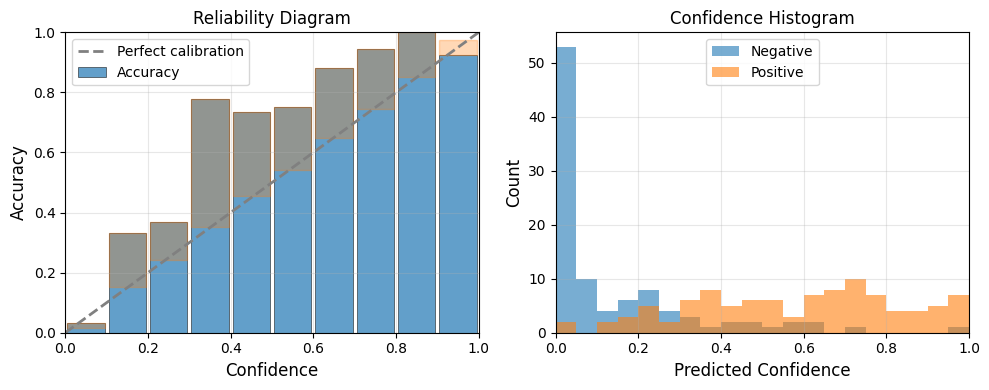

In [ ]:
# Calibration and reliability diagrams
# Use plot_reliability_from_predictions for convenience - computes calibration internally
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Reliability diagram with ECE annotation and gap visualization
# n_bins=10 is standard; the function computes and displays ECE automatically
vis.plot_reliability_from_predictions(y_true, y_score, n_bins=10, ax=axes[0])
axes[0].set_title('Reliability Diagram (10 uniform bins)')

vis.plot_confidence_histogram(y_score, labels=y_true, ax=axes[1])
axes[1].set_title('Confidence Histogram')

plt.tight_layout()
plt.show()

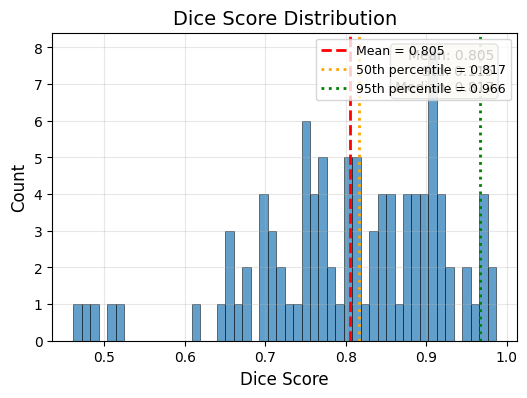

In [ ]:
# Error histogram for segmentation metrics
# Simulating typical Dice scores: most cases good (0.7-0.9), some failure cases in tail
dice_scores = np.random.beta(8, 2, 100)  # Left-skewed distribution typical for Dice

fig, ax = plt.subplots(figsize=(8, 5))
vis.plot_error_histogram(
    dice_scores, 
    bins=15,  # Fewer bins for cleaner visualization
    xlabel='Dice Score', 
    title='Dice Score Distribution',
    ax=ax
)
# Legend auto-positions to upper left (opposite of data mass)
# Stats box shows n, mean, std
plt.show()


## 6. Aggregation & Stratification

Bootstrap CI and stratified aggregation by site/scanner.


In [13]:
try:
    from medeval.core.aggregate import bootstrap_ci, stratified_aggregate
    
    # Per-case metrics from 20 samples across 2 sites
    np.random.seed(0)
    dice_scores = np.random.rand(20) * 0.3 + 0.6  # Dice scores 0.6-0.9
    site_ids = np.array([0] * 10 + [1] * 10)  # Use integer IDs
    
    # Bootstrap 95% CI
    mean, ci_low, ci_high = bootstrap_ci(dice_scores, confidence=0.95, n_bootstrap=1000)
    print(f"Dice: {mean:.4f} [95% CI: {ci_low:.4f}, {ci_high:.4f}]")
    
    # Stratified by site (metrics must be a dict)
    metrics_dict = {'dice': dice_scores}
    strat_results = stratified_aggregate(metrics_dict, site_ids)
    print(f"\nStratified by site:")
    for stratum, metrics in strat_results.items():
        print(f"  Site {stratum}: {metrics}")
except ImportError:
    print("Aggregate module not available")


Dice: 0.7745 [95% CI: 0.7375, 0.8096]

Stratified by site:
  Site dice: {'0': (0.7847298849943628, 0.7516439926248863, 0.8195175872009632), '1': (0.7642030097191956, 0.7010595009149484, 0.8212069282560661)}


## 7. CLI

Batch evaluation from command line with YAML/JSON config.


In [14]:
# CLI usage example (run in terminal)
print("""CLI examples:
  medeval segmentation --pred pred.nii.gz --target target.nii.gz --spacing 1,1,3
  medeval classification --pred probs.csv --target labels.csv --ci
  medeval detection --pred boxes.json --target gt.json --iou 0.5
  medeval --config eval_config.yaml  # Batch evaluation from config file
""")


CLI examples:
  medeval segmentation --pred pred.nii.gz --target target.nii.gz --spacing 1,1,3
  medeval classification --pred probs.csv --target labels.csv --ci
  medeval detection --pred boxes.json --target gt.json --iou 0.5
  medeval --config eval_config.yaml  # Batch evaluation from config file



## 8. IO & Interoperability

Supports NumPy, PyTorch, NIfTI (SimpleITK), and optional MONAI/torchmetrics interop.


In [15]:
from medeval.core.io import load_image, get_spacing_from_header, get_nifti_spacing
from medeval.core.typing import as_tensor, to_device

# Convert between formats
arr_np = np.random.rand(32, 64, 64)
arr_torch = as_tensor(arr_np)  # NumPy -> PyTorch
print(f"NumPy {arr_np.shape} -> PyTorch {arr_torch.shape}")

# GPU support (if available)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
arr_gpu = as_tensor(arr_np, device=device)
print(f"Device: {arr_gpu.device}")

# Spacing utilities info
print("\nSpacing utilities available:")
print("  - get_spacing_from_header(path): Auto-detect format and extract spacing")
print("  - get_nifti_spacing(path): Extract from NIfTI files")
print("  - get_sitk_spacing(path): Extract from SimpleITK-readable files")
print("  - get_dicom_spacing(path): Extract from DICOM files")


NumPy (32, 64, 64) -> PyTorch torch.Size([32, 64, 64])
Device: cpu

Spacing utilities available:
  - get_spacing_from_header(path): Auto-detect format and extract spacing
  - get_nifti_spacing(path): Extract from NIfTI files
  - get_sitk_spacing(path): Extract from SimpleITK-readable files
  - get_dicom_spacing(path): Extract from DICOM files
